# Cloud Querying and Exploratory Visualization

Connect to the Data Warehouse architected on Google Cloud, extract aggregate business metrics, and generate initial visualizations to support strategic decisions.

> [!WARNING]
> Before starting this notebook, make sure you have successfully executed the infrastructure setup script: `scripts/setup_star_schema.sh`.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account

# Set the global style for plots
sns.set_theme(style="whitegrid")

PROJECT_ID = 'ccbd-20260619-danieletambone'

# Authentication via Service Account
key_path = os.environ['GOOGLE_APPLICATION_CREDENTIALS']
credentials = service_account.Credentials.from_service_account_file(
    key_path, scopes=['https://www.googleapis.com/auth/cloud-platform'])
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

print(f"✅ Successfully connected to BigQuery! Project: {client.project}")

✅ Successfully connected to BigQuery! Project: ccbd-20260619-danieletambone


In [2]:
from src.bq_helper import show_and_run, run_query

DATASET = '`ccbd-20260619-danieletambone.cart_dataset`'

sanity_check_sql = f'''
SELECT 
  COUNT(*) AS total_transactions,
  COUNT(DISTINCT CustomerID) AS total_unique_customers,
  COUNT(DISTINCT StockCode) AS total_unique_products,
  COUNT(DISTINCT Country) AS total_countries
FROM {DATASET}.raw_online_retail
'''

print("--- SANITY CHECK: Data Validation ---")
df_sanity = run_query(client, sanity_check_sql, preview=False)
display(df_sanity)

--- SANITY CHECK: Data Validation ---


,total_transactions,total_unique_customers,total_unique_products,total_countries
0,530104,4339,3922,38


## Query

In [3]:
from src.plots import plot_revenue_trend, plot_geographic_AOV, plot_heatmap_orari, rfm_scatter, plot_cohort_heatmap, plot_pareto

### Query 1: Time Series Analysis: Revenue and Volume Trends

**Objective:** Analyze the temporal trend of total revenue and order volume on a monthly basis to identify business seasonality and operational peaks.

**Business Logic:** This analysis allows management to plan logistical resources and marketing campaigns. Using a dual-axis chart enables the verification of the correlation between the number of unique transactions (distinct `InvoiceNo`) and the generated monetary value.

**Execution of file: `sql/query/01_query.sql`**

```sql
SELECT
  FORMAT_DATE('%Y-%m', d.date_key) AS month_year,
  COUNT(DISTINCT f.InvoiceNo) AS total_orders,
  ROUND(SUM(f.TotalAmount), 2) AS total_revenue

FROM 
  `ccbd-20260619-danieletambone.cart_dataset.fact_sales` f
INNER JOIN 
  `ccbd-20260619-danieletambone.cart_dataset.dim_date` d
  ON f.date_id_sk = d.date_id_sk

GROUP BY 
  month_year
ORDER BY 
  month_year ASC;
```

Dry-run: This query will process 0.013 GB

Query 1 completed! Here is the monthly revenue trend:


,month_year,total_orders,total_revenue
0,2010-12,1559,823746.14
1,2011-01,1086,691364.56
2,2011-02,1100,523631.89
3,2011-03,1454,717639.36
4,2011-04,1246,537808.62
5,2011-05,1681,770536.02
6,2011-06,1533,761739.90
7,2011-07,1475,719221.19
8,2011-08,1361,759138.38
9,2011-09,1837,1058590.17


/Users/daniele/Documents/CART/src/plots.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_trend['month_year'], rotation=45, ha='right')


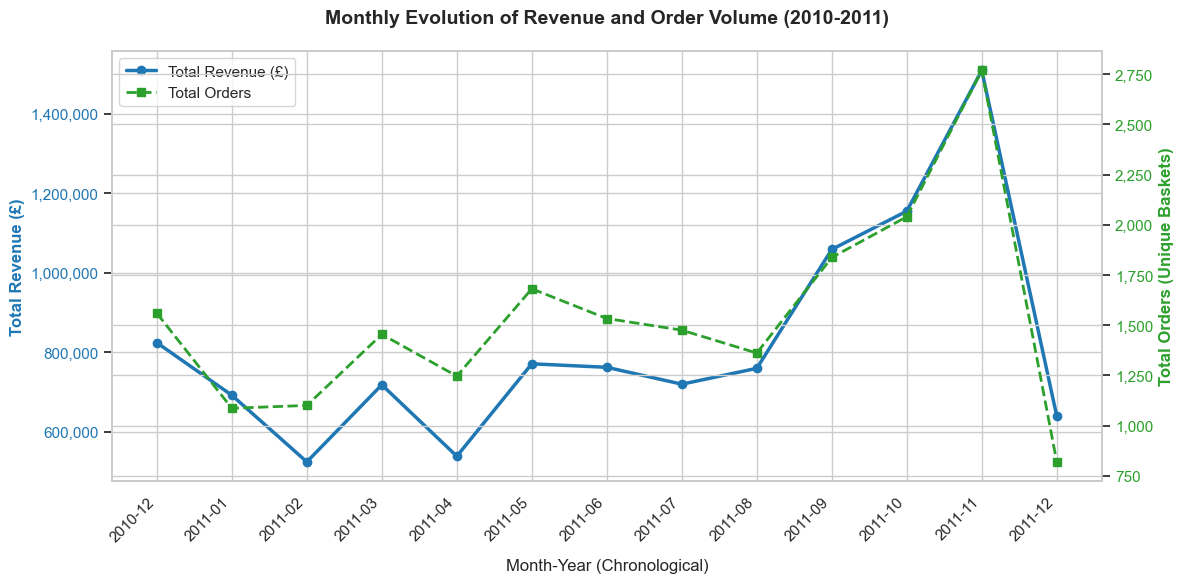

In [4]:
df_trend = show_and_run(client, 'query/01_query.sql')

print("\nQuery 1 completed! Here is the monthly revenue trend:")
display(df_trend)
plot_revenue_trend(df_trend)

### Query 2: Sales Geography: International Market Performance

**Objective:** Map the geographic distribution of total revenue across international markets by excluding the highly dominant domestic market (UK).

**Business Logic:** The United Kingdom accounts for the vast majority of transactions, severely skewing global visualizations and making other countries invisible on a shared scale. To enable a meaningful comparative analysis of cross-border performance, this plot isolates the top 10 foreign markets, highlighting key areas for international business expansion and B2B revenue streams.

**Execution of file: `sql/query/02_query.sql`**

```sql
SELECT
    c.country,
    COUNT(DISTINCT f.InvoiceNo) AS total_orders,
    ROUND(SUM(f.TotalAmount), 2) AS total_revenue,
    ROUND(SUM(f.TotalAmount) / COUNT(DISTINCT f.InvoiceNo), 2) AS average_order_value
FROM
    `ccbd-20260619-danieletambone.cart_dataset.fact_sales` f
    INNER JOIN
    `ccbd-20260619-danieletambone.cart_dataset.dim_customers` c
    ON f.customer_id_sk = c.customer_id_sk
GROUP BY
    country
ORDER BY
    total_revenue DESC;
```

Dry-run: This query will process 0.013 GB

Query 2 completed! Here is the revenue ranking for top international markets:


,country,total_orders,total_revenue,average_order_value
2,Netherlands,94,285446.34,3036.66
3,EIRE,260,265545.90,1021.33
4,Germany,457,228867.14,500.80
5,France,389,209024.05,537.34
6,Australia,42,132620.44,3157.63
7,Spain,100,66488.81,664.89
8,Switzerland,55,57222.85,1040.42
9,Belgium,102,43117.13,422.72
10,Sweden,36,38378.33,1066.06
11,Japan,19,37416.37,1969.28


/Users/daniele/Documents/CART/src/plots.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


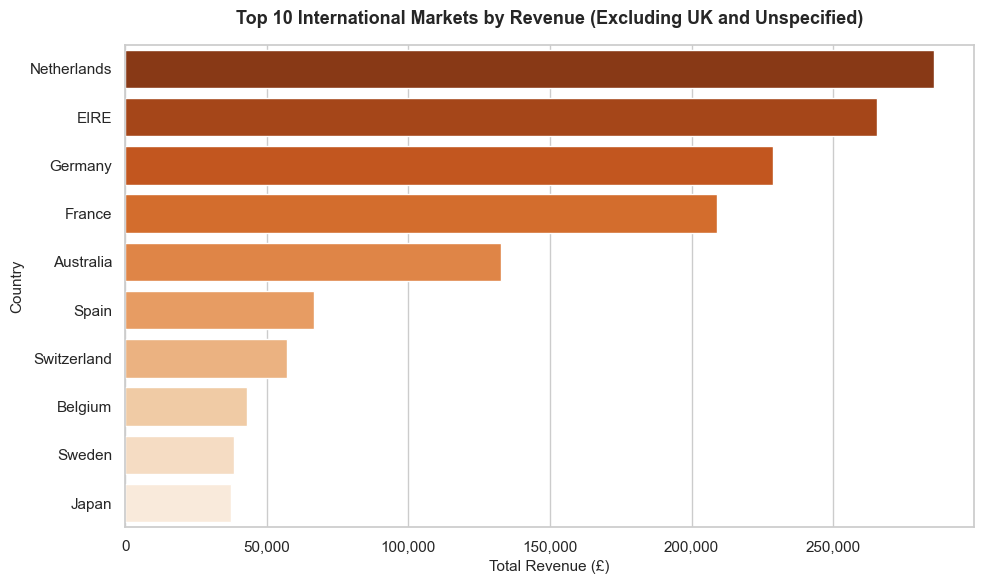

In [5]:
df_geographic = show_and_run(client, 'query/02_query.sql')

print("\nQuery 2 completed! Here is the revenue ranking for top international markets:")
display(df_geographic[(df_geographic['country'] != 'United Kingdom') & (df_geographic['country'] != 'Unspecified')].head(10))
plot_geographic_AOV(df_geographic)

### Query 3: Purchasing Behavior: Temporal Heatmap

**Objective:** Identify purchasing patterns by cross-referencing days of the week with daily macro-time brackets.

**Business Logic:** This visualization adopts a Heatmap to immediately highlight traffic peaks. It is crucial for advertising budget allocation (e.g., increasing CPC for Google Ads campaigns during rush hours) and optimizing customer care staff shifts. 

**Execution of file: `sql/query/03_query.sql`**

```sql
SELECT 
  FORMAT_DATE('%A', d.date_key) AS day_of_week,
  
  CASE 
    WHEN EXTRACT(HOUR FROM f.InvoiceDate) BETWEEN 6 AND 12 THEN '1 - Morning (06:00 am - 12:59 pm)'
    WHEN EXTRACT(HOUR FROM f.InvoiceDate) BETWEEN 13 AND 17 THEN '2 - Afternoon (01:00 pm - 05:59 pm)'
    WHEN EXTRACT(HOUR FROM f.InvoiceDate) BETWEEN 18 AND 22 THEN '3 - Evening (06:00 pm - 10:59 pm)'
    ELSE '4 - Night (11:00 pm - 05:59 am)'
  END AS time_of_day,
  
  COUNT(DISTINCT f.InvoiceNo) AS total_orders

FROM 
  `ccbd-20260619-danieletambone.cart_dataset.fact_sales` f
INNER JOIN 
  `ccbd-20260619-danieletambone.cart_dataset.dim_date` d
  ON f.date_id_sk = d.date_id_sk

GROUP BY 
  day_of_week, 
  time_of_day
ORDER BY 
  total_orders DESC;
```

Dry-run: This query will process 0.013 GB

Query 3 completed! Here are the macro time brackets:


,day_of_week,time_of_day,total_orders
0,Thursday,2 - Afternoon (01:00 pm - 05:59 pm),2032
1,Wednesday,1 - Morning (06:00 am - 12:59 pm),1932
2,Thursday,1 - Morning (06:00 am - 12:59 pm),1884
3,Tuesday,1 - Morning (06:00 am - 12:59 pm),1838
4,Wednesday,2 - Afternoon (01:00 pm - 05:59 pm),1755
5,Friday,1 - Morning (06:00 am - 12:59 pm),1750
6,Tuesday,2 - Afternoon (01:00 pm - 05:59 pm),1707
7,Monday,1 - Morning (06:00 am - 12:59 pm),1574
8,Monday,2 - Afternoon (01:00 pm - 05:59 pm),1550
9,Friday,2 - Afternoon (01:00 pm - 05:59 pm),1378


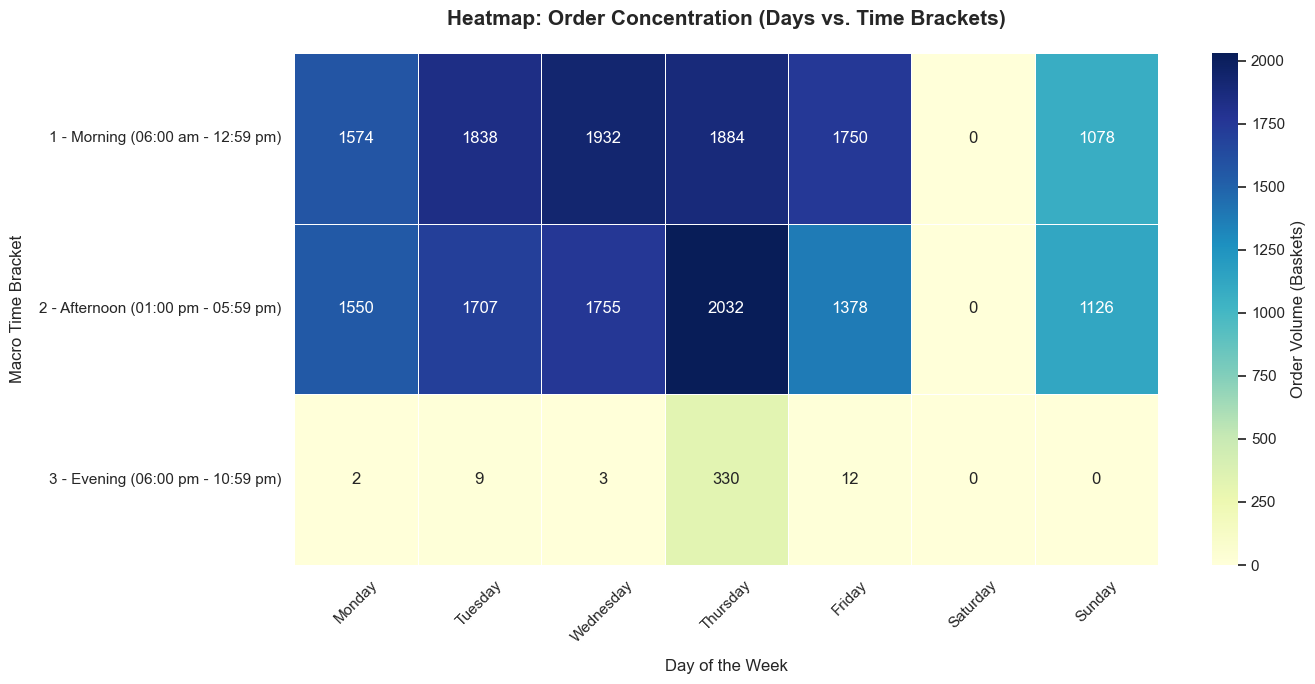

In [6]:
df_time = show_and_run(client, 'query/03_query.sql')

print("\nQuery 3 completed! Here are the macro time brackets:")
display(df_time.head(10))
plot_heatmap_orari(df_time)

### Query 4: RFM Segmentation: Customer Spatial Distribution (Random Sampling)

**Objective:** Visualize the distribution of customers in the three-dimensional space composed of Recency, Frequency, and Monetary values.

**Business Logic & Data Engineering:** Extracting RFM data produces one row for each unique customer. This chart is the fundamental starting point to understand the customer structure before applying the clustering algorithm (K-Means). It allows for visual identification of different behavioral clusters:
* **Whales:** High frequency, high spend, very low recency (top left).
* **At-Risk Churners:** High past spend, but very high recency (top right).
* **High-Potential New Customers:** Low frequency but high spend and low recency.

*Engineering constraint:* Although the dataset only has ~4,300 customers (easily manageable in local RAM), in a real Big Data context (e.g., tens of millions of active users), transferring and rendering the entire set would cause *Out-Of-Memory* errors and crash the Jupyter kernel. To adhere to engineering best practices, the query uses **Server-Side Random Sampling**: RFM metrics are calculated with absolute precision on all data, but only a representative sample (e.g., 20%) is sent to the notebook for the Scatter Plot, preventing bottlenecks and visual overplotting.

**Execution of file: `sql/query/04_query.sql`**

```sql
WITH reference_date AS (
  SELECT MAX(DATE(InvoiceDate)) AS max_date
  FROM `ccbd-20260619-danieletambone.cart_dataset.fact_sales`
),

rfm_base AS (
  SELECT 
    c.CustomerID,
    DATE_DIFF((SELECT max_date FROM reference_date), MAX(DATE(f.InvoiceDate)), DAY) AS Recency,
    COUNT(DISTINCT f.InvoiceNo) AS Frequency,
    ROUND(SUM(f.TotalAmount), 2) AS Monetary
  FROM 
    `ccbd-20260619-danieletambone.cart_dataset.fact_sales` f
  INNER JOIN 
    `ccbd-20260619-danieletambone.cart_dataset.dim_customers` c
    ON f.customer_id_sk = c.customer_id_sk
  WHERE 
    c.CustomerID != 0 
  GROUP BY 
    c.CustomerID
)
SELECT * FROM rfm_base
WHERE RAND() < 0.20
ORDER BY Monetary DESC, Frequency DESC;
```

Dry-run: This query will process 0.017 GB

Query 4 completed! Extracted a representative sample of 840 customers for visualization.


,CustomerID,Recency,Frequency,Monetary
0,18102,0,60,259657.30
1,17450,8,46,194550.79
2,12415,24,21,124914.53
3,17511,2,31,91062.38
4,16029,38,63,81024.84
5,16684,4,28,66653.56
6,15061,3,48,54534.14
7,13798,1,57,37153.85
8,15838,11,19,33643.08
9,17404,4,15,31906.82


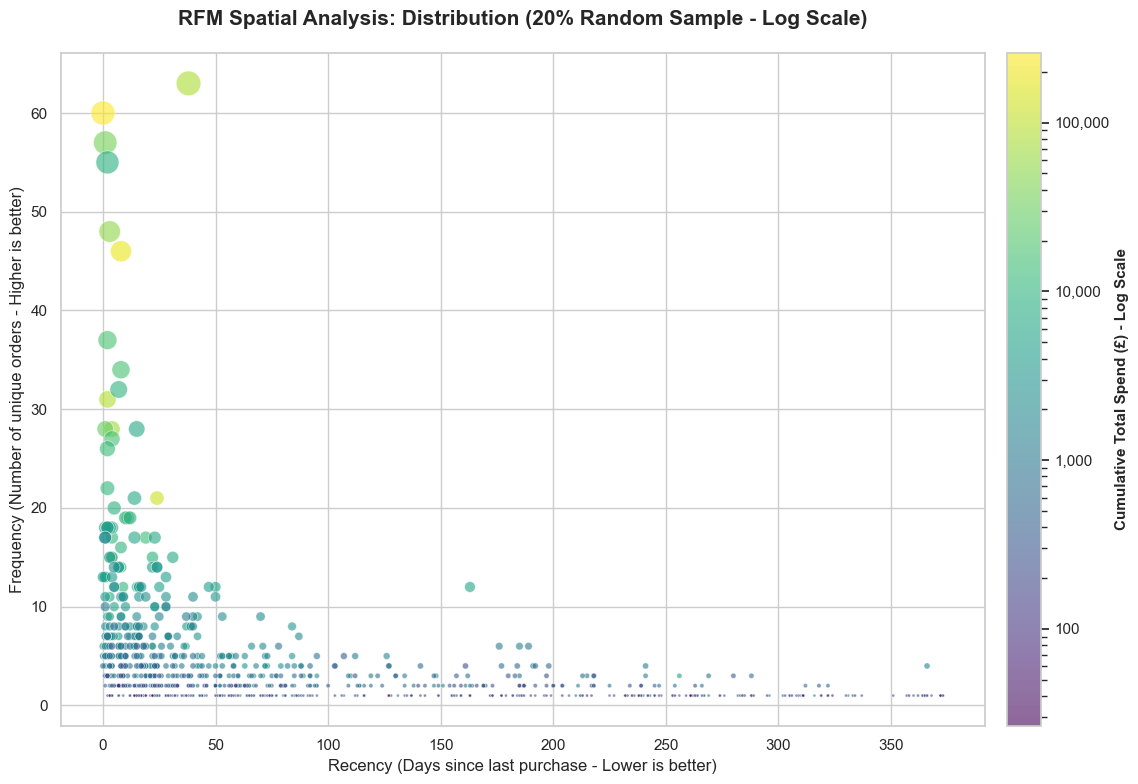

In [7]:
df_rfm_sample = show_and_run(client, 'query/04_query.sql')

print(f"\nQuery 4 completed! Extracted a representative sample of {len(df_rfm_sample)} customers for visualization.")
display(df_rfm_sample.head(10))
rfm_scatter(df_rfm_sample)

### Query 5: Cohort Analysis: Customer Retention Matrix (Customer Loyalty)

**Objective:** Measure the e-commerce's ability to retain customers over time by grouping them by their first purchase month (Cohort) and tracking their purchases in subsequent months.

**Business Logic:** This analysis answers the question: *"If I acquire 100 customers in January, how many of them return to buy in February, March, etc.?"*.

**Execution of file: `sql/query/05_query.sql`**

```sql
WITH customer_cohort AS (
  -- 1. Find the month of the FIRST purchase for each customer (Their Cohort)
  SELECT 
    c.CustomerID,
    DATE_TRUNC(MIN(DATE(f.InvoiceDate)), MONTH) AS cohort_month
  FROM 
    `ccbd-20260619-danieletambone.cart_dataset.fact_sales` f
  INNER JOIN 
    `ccbd-20260619-danieletambone.cart_dataset.dim_customers` c
    ON f.customer_id_sk = c.customer_id_sk
  WHERE 
    c.CustomerID != 0 -- Exclude anonymous (guest) customers
  GROUP BY 
    c.CustomerID
),

customer_purchases AS (
  -- 2. Extract all months in which a customer made at least one purchase
  SELECT DISTINCT
    c.CustomerID,
    DATE_TRUNC(DATE(f.InvoiceDate), MONTH) AS purchase_month
  FROM 
    `ccbd-20260619-danieletambone.cart_dataset.fact_sales` f
  INNER JOIN 
    `ccbd-20260619-danieletambone.cart_dataset.dim_customers` c
    ON f.customer_id_sk = c.customer_id_sk
  WHERE 
    c.CustomerID != 0
)

-- 3. Join the two tables to calculate the months passed since the first purchase
SELECT 
  FORMAT_DATE('%Y-%m', cc.cohort_month) AS acquisition_month,
  
  -- Calculate the retention month index (Month 0 = first purchase, Month 1 = next month, etc.)
  DATE_DIFF(cp.purchase_month, cc.cohort_month, MONTH) AS retention_month_index,
  
  -- Count how many unique customers of that cohort were active in that specific month
  COUNT(DISTINCT cp.CustomerID) AS active_customers

FROM 
  customer_cohort cc
INNER JOIN 
  customer_purchases cp
  ON cc.CustomerID = cp.CustomerID

GROUP BY 
  acquisition_month, 
  retention_month_index
ORDER BY 
  acquisition_month ASC, 
  retention_month_index ASC;
```

Dry-run: This query will process 0.009 GB

Query 5 completed! Here is the data for the retention Heatmap:


,acquisition_month,retention_month_index,active_customers
0,2010-12,0,885
1,2010-12,1,324
2,2010-12,2,286
3,2010-12,3,340
4,2010-12,4,321
5,2010-12,5,352
6,2010-12,6,321
7,2010-12,7,309
8,2010-12,8,313
9,2010-12,9,350


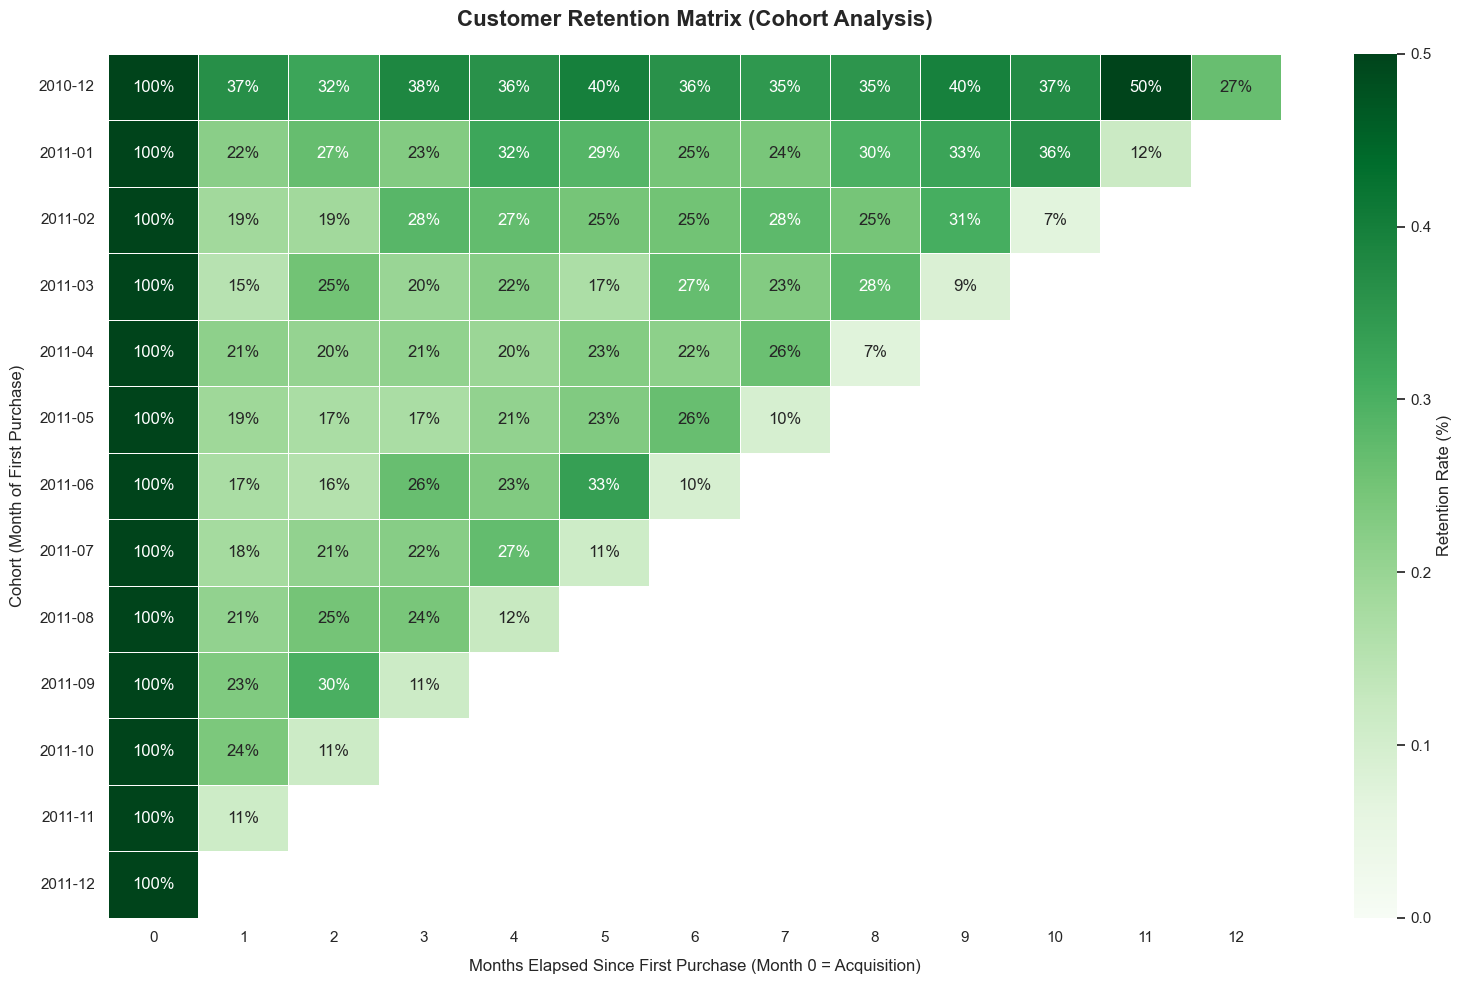

In [8]:
df_cohort = show_and_run(client, 'query/05_query.sql')

print("\nQuery 5 completed! Here is the data for the retention Heatmap:")
display(df_cohort.head(15))
plot_cohort_heatmap(df_cohort)

### Query 6: Pareto Analysis: The 80/20 Rule on Products

**Objective:** Identify the absolute "Best Sellers" of the company and measure their percentage weight on global revenue (Cumulative Percentage).

**Business Logic:** The Pareto principle suggests that a small fraction of the catalog generates the majority of revenues. Through a dual-axis chart (Bars for absolute revenues, Line for cumulative percentage), it is possible to visually isolate the "Vital Few" products. These strategic items must never suffer stock-outs, as their depletion would cause disproportionate economic damage compared to the catalog average.

**Execution of file: `sql/query/06_query.sql`**

```sql
WITH product_revenue AS (
  -- 1. Calculate the total revenue for each physical product
  SELECT 
    p.StockCode,
    p.Description AS product_name,
    SUM(f.TotalAmount) AS total_revenue
  FROM 
    `ccbd-20260619-danieletambone.cart_dataset.fact_sales` f
  INNER JOIN 
    `ccbd-20260619-danieletambone.cart_dataset.dim_products_scd` p
    ON f.product_id_sk = p.product_id_sk
  WHERE 
    p.product_type = 'Physical Product'
  GROUP BY 
    p.StockCode, 
    product_name
),

cumulative_data AS (
  -- 2. Use Window Functions to calculate the running cumulative sum and the global total
  SELECT 
    product_name,
    total_revenue,
    -- Running sum: current row + all preceding rows
    SUM(total_revenue) OVER(ORDER BY total_revenue DESC) AS cumulative_revenue,
    -- Global sum: total of all products to calculate the percentage
    SUM(total_revenue) OVER() AS global_revenue
  FROM 
    product_revenue
)

-- 3. Calculate the final percentage
SELECT 
  product_name,
  ROUND(total_revenue, 2) AS total_revenue,
  ROUND(cumulative_revenue, 2) AS cumulative_revenue,
  -- Calculation of the cumulative percentage (e.g., 15.5%)
  ROUND((cumulative_revenue / global_revenue) * 100, 2) AS cumulative_percentage
FROM 
  cumulative_data
ORDER BY 
  total_revenue DESC
LIMIT 50; -- Limit to the top 50 to display the absolute "Best Sellers"
```

Dry-run: This query will process 0.009 GB

Query 6 completed! Here are the Top Products and their impact on revenue:


,product_name,total_revenue,cumulative_revenue,cumulative_percentage
0,REGENCY CAKESTAND 3 TIER,174484.74,174484.74,1.70
1,"PAPER CRAFT , LITTLE BIRDIE",168469.60,342954.34,3.34
2,WHITE HANGING HEART T-LIGHT HOLDER,104223.29,447177.63,4.35
3,PARTY BUNTING,99504.33,546681.96,5.32
4,JUMBO BAG RED RETROSPOT,94340.05,641022.01,6.24
5,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,722722.93,7.03
6,RABBIT NIGHT LIGHT,66964.99,789687.92,7.68
7,PAPER CHAIN KIT 50'S CHRISTMAS,64952.29,854640.21,8.31
8,ASSORTED COLOUR BIRD ORNAMENT,59094.93,913735.14,8.89
9,CHILLI LIGHTS,54117.76,967852.90,9.42


/Users/daniele/Documents/CART/src/plots.py:227: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_pareto['product_name'], rotation=90, fontsize=9)


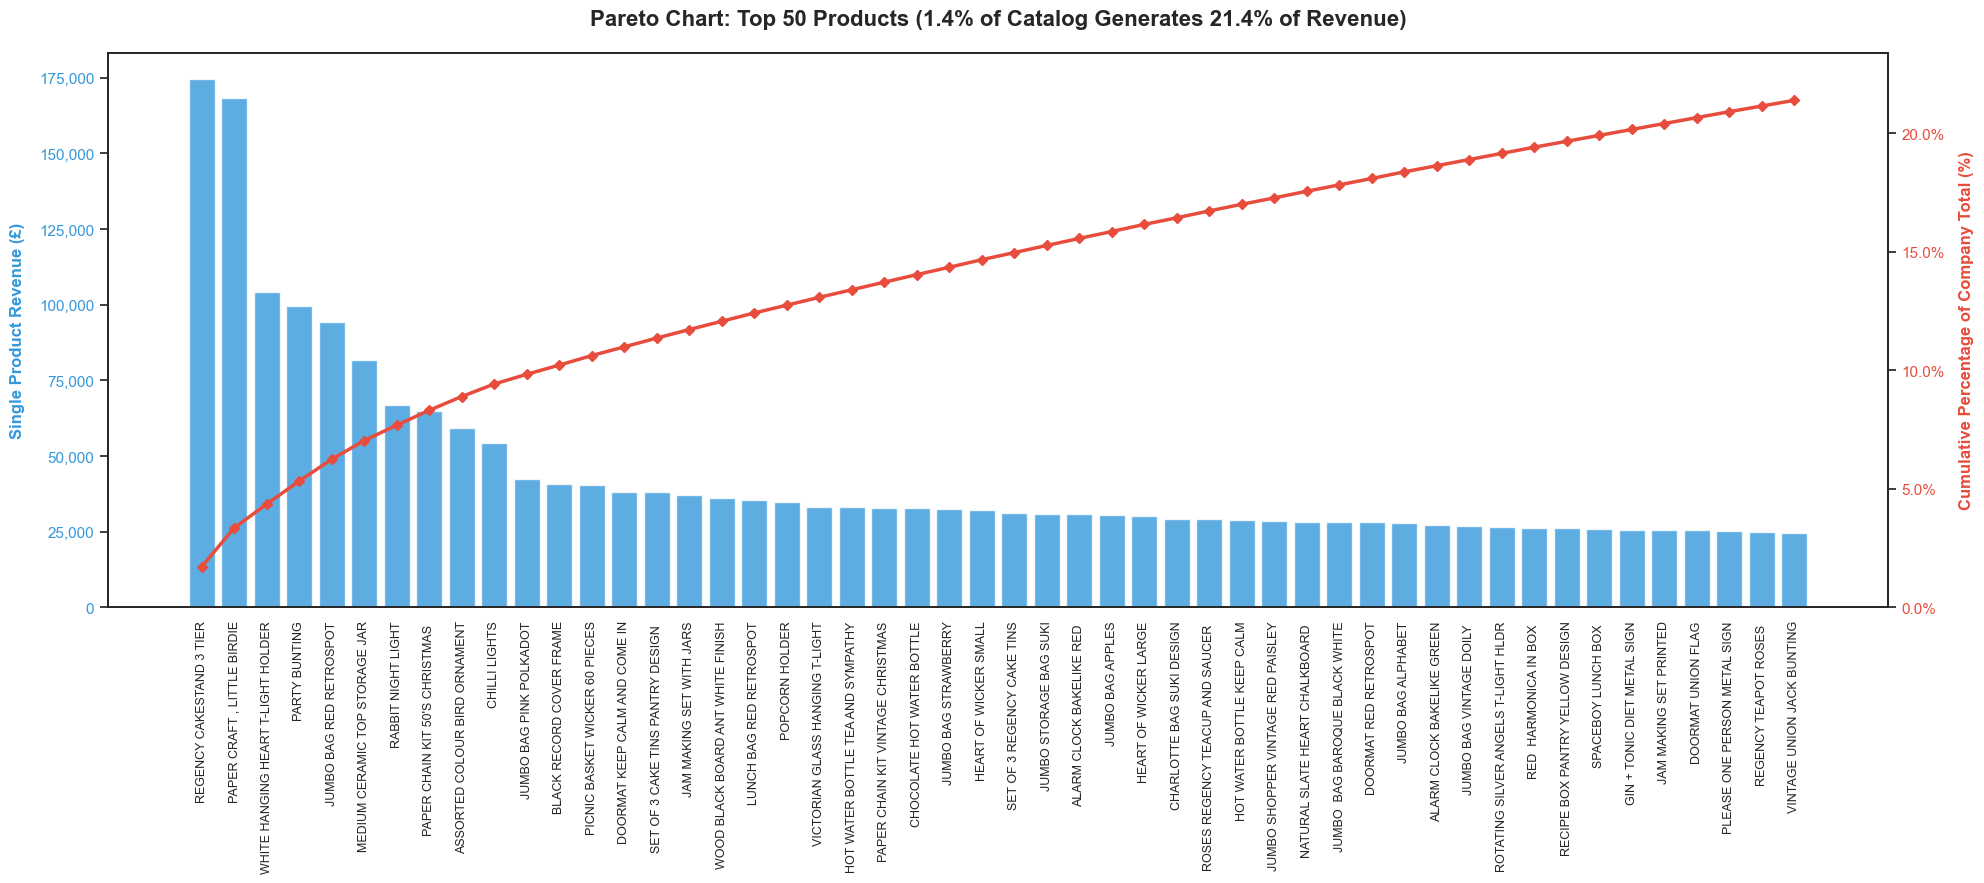

In [9]:
df_pareto = show_and_run(client, 'query/06_query.sql')

print("\nQuery 6 completed! Here are the Top Products and their impact on revenue:")
display(df_pareto)
plot_pareto(df_pareto)

## Data Enrichment - BigQuery ML

In this phase, we move beyond descriptive analytics into predictive clustering. We utilize BigQuery's serverless Machine Learning capabilities (BQML) to train a K-Means model directly on the Data Warehouse, avoiding heavy data transfers.

In [10]:
print("Starting K-Means model training on BigQuery ML...")

with open('sql/model/01_train_kmeans.sql', 'r') as file:
    # Replace the placeholder with the DATASET variable defined at the start
    create_model_sql = file.read().replace('{DATASET}', DATASET)

# Execute the query (this will take a few seconds)
client.query(create_model_sql).result()
print('✅ K-Means model successfully trained and saved in BigQuery!')

Starting K-Means model training on BigQuery ML...
✅ K-Means model successfully trained and saved in BigQuery!


In [11]:
print("\nModel evaluation metrics (Davies-Bouldin Index):")

with open('sql/model/02_evaluate_kmeans.sql', 'r') as file:
    evaluate_sql = file.read().replace('{DATASET}', DATASET)

df_eval = run_query(client, evaluate_sql, preview=False)
display(df_eval)


Model evaluation metrics (Davies-Bouldin Index):


,davies_bouldin_index,mean_squared_distance
0,1.067473,1.129963


In [12]:
print("\nData Enrichment: Assigning Clusters to customers and saving...")

with open('sql/model/03_predict_kmeans.sql', 'r') as file:
    predict_sql = file.read().replace('{DATASET}', DATASET)

client.query(predict_sql).result()
print('✅ Table dim_customers_enriched created successfully!')


Data Enrichment: Assigning Clusters to customers and saving...
✅ Table dim_customers_enriched created successfully!


In [13]:
with open('sql/model/04_profile_kmeans.sql', 'r') as file:
    profiling_sql = file.read().replace('{DATASET}', DATASET)

df_profiles = run_query(client, profiling_sql, preview=False)
display(df_profiles)

,Cluster_Segment,customer_count,avg_recency_days,avg_frequency_orders,avg_monetary_gbp
0,1,26,5.0,66.4,85904.35
1,2,3227,41.0,4.7,1856.91
2,3,1085,246.0,1.6,631.92


## Executive Summary: Customer Segmentation Insights

The clustering operation yielded statistically robust results, successfully categorizing the customer base into three distinct behavioral segments. Below is the business translation of the metrics extracted by the K-Means algorithm.

### 1. Model Quality

The model successfully partitioned the customer base into three highly distinct behavioral groups. By minimizing the Davies-Bouldin index, the algorithm ensured that the segments represent clear, non-overlapping purchasing patterns, providing a solid foundation for targeted marketing strategies.

### 2. Cluster Profiles (Business Personas)

#### Cluster 1: The "Whales" (High-Value VIPs)
* *Data:* 26 customers | Avg Recency: 5 days | Avg Frequency: 66.4 | Avg Monetary: £85,904.
* *Analysis:* This represents the company's core asset. These are high-frequency, high-spend clients with extremely low recency. They act as "VIPs" and should be prioritized for exclusive white-glove service, loyalty programs, and early access to new product lines.


#### Cluster 2: The "Engine" (Active & Loyal)
* *Data:* 3,227 customers (The Majority) | Avg Recency: 41 days | Avg Frequency: 4.7 | Avg Monetary: £1,857.
* *Analysis:* These are the steady revenue drivers. They purchase regularly and remain engaged with the brand. Marketing efforts should focus on retention and cross-selling to gradually increase their average order value and shift them toward the "VIP" segment.


#### Cluster 3: The "At-Risk/Churned" (Dormant Customers)
* *Data:* 1,085 customers | Avg Recency: 246 days | Avg Frequency: 1.6 | Avg Monetary: £632.
* *Analysis:* This segment includes both at-risk and churned customers who have not interacted with the brand for an average of 8 months. Their low frequency and high recency suggest they have largely abandoned the store. The strategy here should be cost-effective re-engagement campaigns; however, high-budget acquisition spend should be avoided to prioritize more profitable segments.